In [26]:
%pip install seaborn plotly pandas numpy matplotlib nbformat

Defaulting to user installation because normal site-packages is not writeable
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)

   ---------------------------------------- 0/2 [fastjsonschema]
   ---------------------------------------- 0/2 [fastjsonschema]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]

Note: y


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
cwd = Path.cwd()
if cwd.name == "notebooks":
    BASE = cwd.parent
elif (cwd / "notebooks").exists():
    BASE = cwd
else:
    BASE = cwd

PROCESSED = BASE / "data" / "processed"
RAW       = BASE / "data" / "raw"
CHARTS    = BASE / "reports" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("PROCESSED:", PROCESSED)
print("RAW:", RAW)

BASE: E:\PROJECTS\mutual-fund-dashboard
PROCESSED: E:\PROJECTS\mutual-fund-dashboard\data\processed
RAW: E:\PROJECTS\mutual-fund-dashboard\data\raw


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

BASE = Path.cwd()
if BASE.name == "notebooks":
    BASE = BASE.parent
elif (BASE / "notebooks").exists():
    BASE = BASE
else:
    raise RuntimeError("Unable to locate the project root from the current working directory")

PROCESSED = BASE / "data" / "processed"
RAW       = BASE / "data" / "raw"
CHARTS    = BASE / "reports" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# ── Load all datasets ─────────────────────────────────────
fund_master  = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")

# nav_history from raw to keep amfi_code
nav_history = pd.read_csv(RAW / "02_nav_history.csv")
nav_history.columns = nav_history.columns.str.strip().str.lower().str.replace(" ", "_")
if "date" not in nav_history.columns:
    raise KeyError("Expected 'date' column in raw nav_history CSV")
if "nav" not in nav_history.columns:
    raise KeyError("Expected 'nav' column in raw nav_history CSV")

nav_history["date_id"] = pd.to_datetime(nav_history["date"], dayfirst=True, errors="coerce")
nav_history = nav_history[nav_history["nav"] > 0].drop_duplicates(subset=["amfi_code", "date"])
nav_history = nav_history[["amfi_code", "date_id", "nav"]]

aum          = pd.read_csv(PROCESSED / "03_aum_by_fund_house_clean.csv")
sip_inflows  = pd.read_csv(PROCESSED / "04_monthly_sip_inflows_clean.csv")
cat_inflows  = pd.read_csv(PROCESSED / "05_category_inflows_clean.csv")
folio        = pd.read_csv(PROCESSED / "06_industry_folio_count_clean.csv")
performance  = pd.read_csv(PROCESSED / "07_scheme_performance_clean.csv")
transactions = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv")
portfolio    = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")
benchmark    = pd.read_csv(PROCESSED / "10_benchmark_indices_clean.csv")

# ── Standardise date columns ──────────────────────────────
aum["date_id"]          = pd.to_datetime(aum["date"], dayfirst=True, errors="coerce")
sip_inflows["date_id"]  = pd.to_datetime(sip_inflows["month"], format="%Y-%m", errors="coerce")
cat_inflows["date_id"]  = pd.to_datetime(cat_inflows["month"], format="%Y-%m", errors="coerce")
folio["date_id"]        = pd.to_datetime(folio["month"], format="%Y-%m", errors="coerce")
transactions["date_id"] = pd.to_datetime(transactions["transaction_date"], errors="coerce")
portfolio["date_id"]    = pd.to_datetime(portfolio["portfolio_date"], format="%Y-%m-%d", errors="coerce")
benchmark["date_id"]    = pd.to_datetime(benchmark["date"], format="%Y-%m-%d", errors="coerce")

print("✅ All datasets loaded and date columns standardised")

✅ All datasets loaded and date columns standardised


In [3]:
import os

# Absolute path — works regardless of where notebook is run from
BASE      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED = os.path.join(BASE, "data", "processed")
RAW       = os.path.join(BASE, "data", "raw")
CHARTS    = os.path.join(BASE, "reports", "charts")
os.makedirs(CHARTS, exist_ok=True)

print("BASE:", BASE)
print("PROCESSED:", PROCESSED)
print("RAW:", RAW)

BASE: E:\PROJECTS\mutual-fund-dashboard
PROCESSED: E:\PROJECTS\mutual-fund-dashboard\data\processed
RAW: E:\PROJECTS\mutual-fund-dashboard\data\raw


In [4]:
import os

# Go up from notebooks/ to mutual-fund-dashboard/
BASE      = os.path.dirname(os.getcwd())
PROCESSED = os.path.join(BASE, "data", "processed")
RAW       = os.path.join(BASE, "data", "raw")
CHARTS    = os.path.join(BASE, "reports", "charts")
os.makedirs(CHARTS, exist_ok=True)

print("BASE:", BASE)
print("PROCESSED:", PROCESSED)
print("RAW:", RAW)

BASE: E:\PROJECTS\mutual-fund-dashboard
PROCESSED: E:\PROJECTS\mutual-fund-dashboard\data\processed
RAW: E:\PROJECTS\mutual-fund-dashboard\data\raw


In [18]:
import os

BASE      = r"E:\PROJECTS\mutual-fund-dashboard"
PROCESSED = os.path.join(BASE, "data", "processed")
RAW       = os.path.join(BASE, "data", "raw")
CHARTS    = os.path.join(BASE, "reports", "charts")
os.makedirs(CHARTS, exist_ok=True)

print("BASE:", BASE)
print("PROCESSED:", PROCESSED)
print("RAW:", RAW)

BASE: E:\PROJECTS\mutual-fund-dashboard
PROCESSED: E:\PROJECTS\mutual-fund-dashboard\data\processed
RAW: E:\PROJECTS\mutual-fund-dashboard\data\raw


In [5]:
# Merge to get scheme names
nav_merged = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left"
)

fig = px.line(
    nav_merged,
    x="date_id", y="nav",
    color="scheme_name",
    title="Daily NAV Trends — All 40 Schemes (2022–2026)",
    labels={"date_id": "Date", "nav": "NAV (₹)", "scheme_name": "Scheme"}
)

# Highlight 2023 bull run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.07,
              annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 correction
fig.add_vrect(x0="2024-06-01", x1="2024-09-30",
              fillcolor="red", opacity=0.07,
              annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(height=600, showlegend=False)
fig.write_html(f"{CHARTS}/01_nav_trends.html")
print(f"Saved: {CHARTS / '01_nav_trends.html'}")

TypeError: unsupported operand type(s) for /: 'str' and 'str'

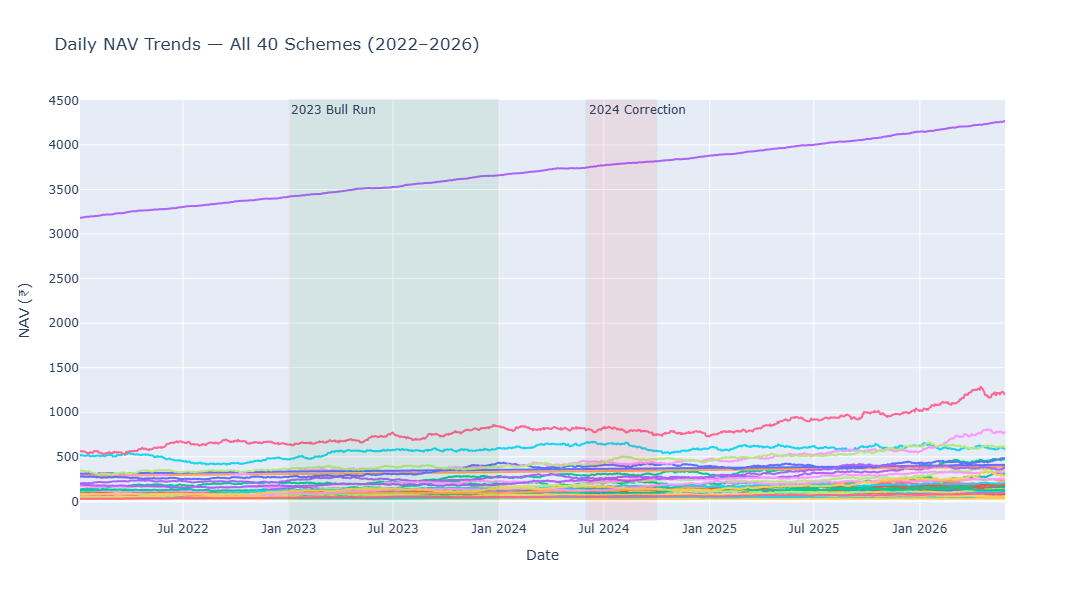

In [6]:
# Merge to get scheme names
nav_merged = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left"
)

fig = px.line(
    nav_merged,
    x="date_id", y="nav",
    color="scheme_name",
    title="Daily NAV Trends — All 40 Schemes (2022–2026)",
    labels={"date_id": "Date", "nav": "NAV (₹)", "scheme_name": "Scheme"}
)

# Highlight 2023 bull run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.07,
              annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 correction
fig.add_vrect(x0="2024-06-01", x1="2024-09-30",
              fillcolor="red", opacity=0.07,
              annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(height=600, showlegend=False)
fig.write_html(f"{CHARTS}/01_nav_trends.html")
fig.show()

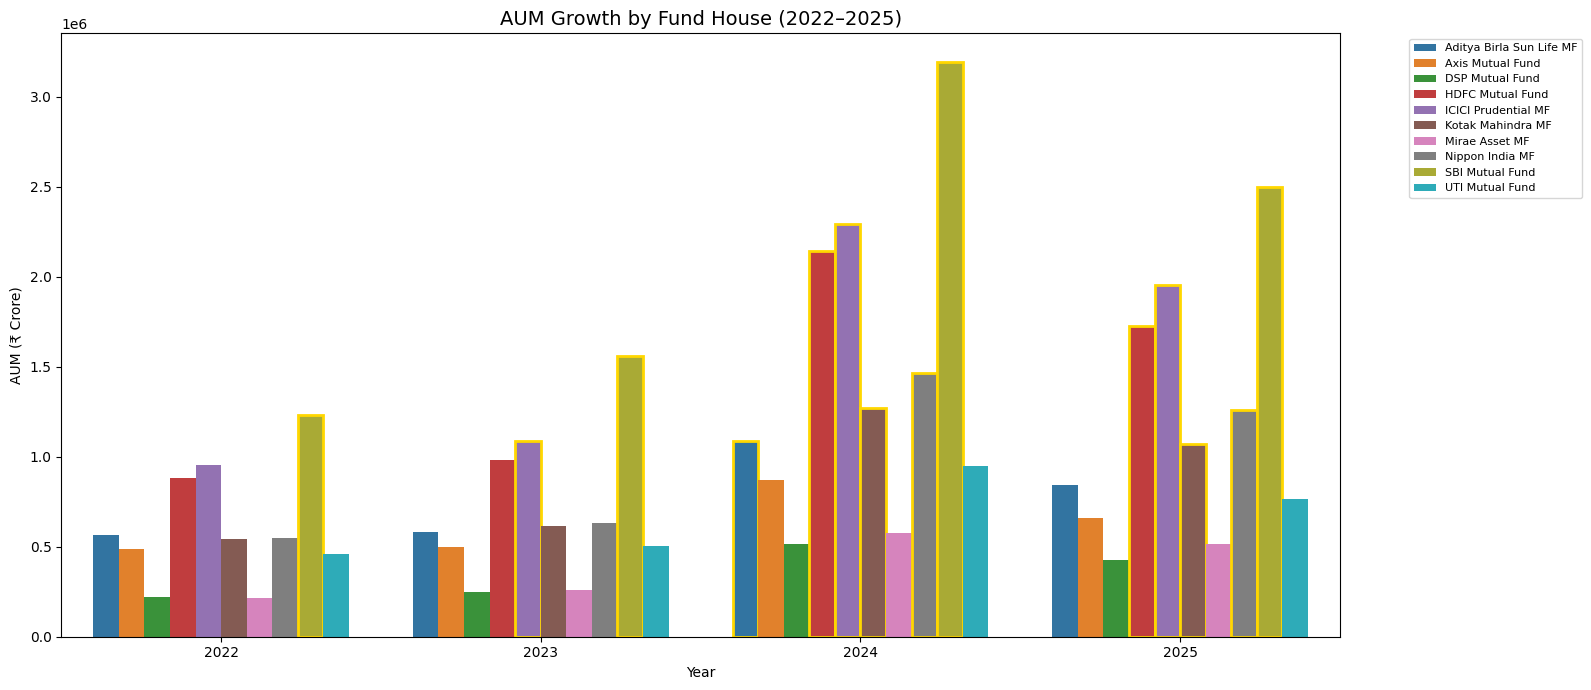

In [7]:
# Extract year from date
aum["year"] = pd.to_datetime(aum["date_id"], errors="coerce").dt.year
aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].sum().reset_index()

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=aum_yearly[aum_yearly["year"].between(2022, 2025)],
    x="year", y="aum_crore", hue="fund_house"
)

# Highlight SBI bars
for bar in ax.patches:
    if bar.get_height() > 1000000:
        bar.set_edgecolor("gold")
        bar.set_linewidth(2)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=14)
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHARTS}/02_aum_growth.png", dpi=150)
plt.show()

In [8]:
# Check columns
print(sip_inflows.columns.tolist())
print(sip_inflows.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct', 'date_id']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct    date_id  
0                   9.10                4.80             NaN 2022-01-01  
1                   8.20                4.85             NaN 2022-02-01  
2                  10.50                5.01             NaN 2022-03-01  
3                   9.52                5.12             NaN 2022-04-01  
4                   8.10                5.15             NaN 2022-05-01  


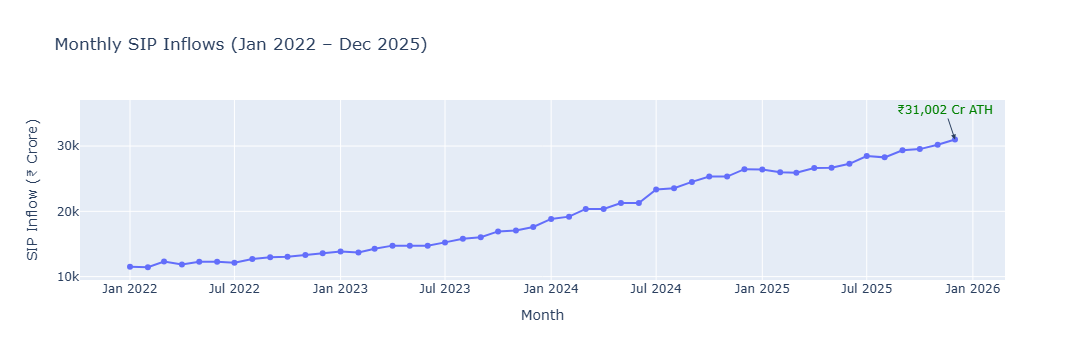

In [9]:
# Adjust column names if needed based on output above
date_col   = "date_id"
amount_col = "sip_inflow_crore"

sip_inflows[date_col] = pd.to_datetime(sip_inflows[date_col], dayfirst=True, errors="coerce")
sip_inflows = sip_inflows.sort_values(date_col)

fig = px.line(
    sip_inflows, x=date_col, y=amount_col,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={date_col: "Month", amount_col: "SIP Inflow (₹ Crore)"},
    markers=True
)

# Annotate all-time high
fig.add_annotation(
    x="2025-12-01", y=sip_inflows[amount_col].max(),
    text="₹31,002 Cr ATH", showarrow=True,
    arrowhead=2, font=dict(color="green", size=12)
)

fig.write_html(f"{CHARTS}/03_sip_trend.html")
fig.show()

In [10]:
print(cat_inflows.columns.tolist())
print(cat_inflows.head())

['month', 'category', 'net_inflow_crore', 'date_id']
     month         category  net_inflow_crore    date_id
0  2024-04        Large Cap            2413.0 2024-04-01
1  2024-04          Mid Cap            3897.0 2024-04-01
2  2024-04        Small Cap            3533.0 2024-04-01
3  2024-04        Flexi Cap            4947.0 2024-04-01
4  2024-04  Large & Mid Cap            4214.0 2024-04-01


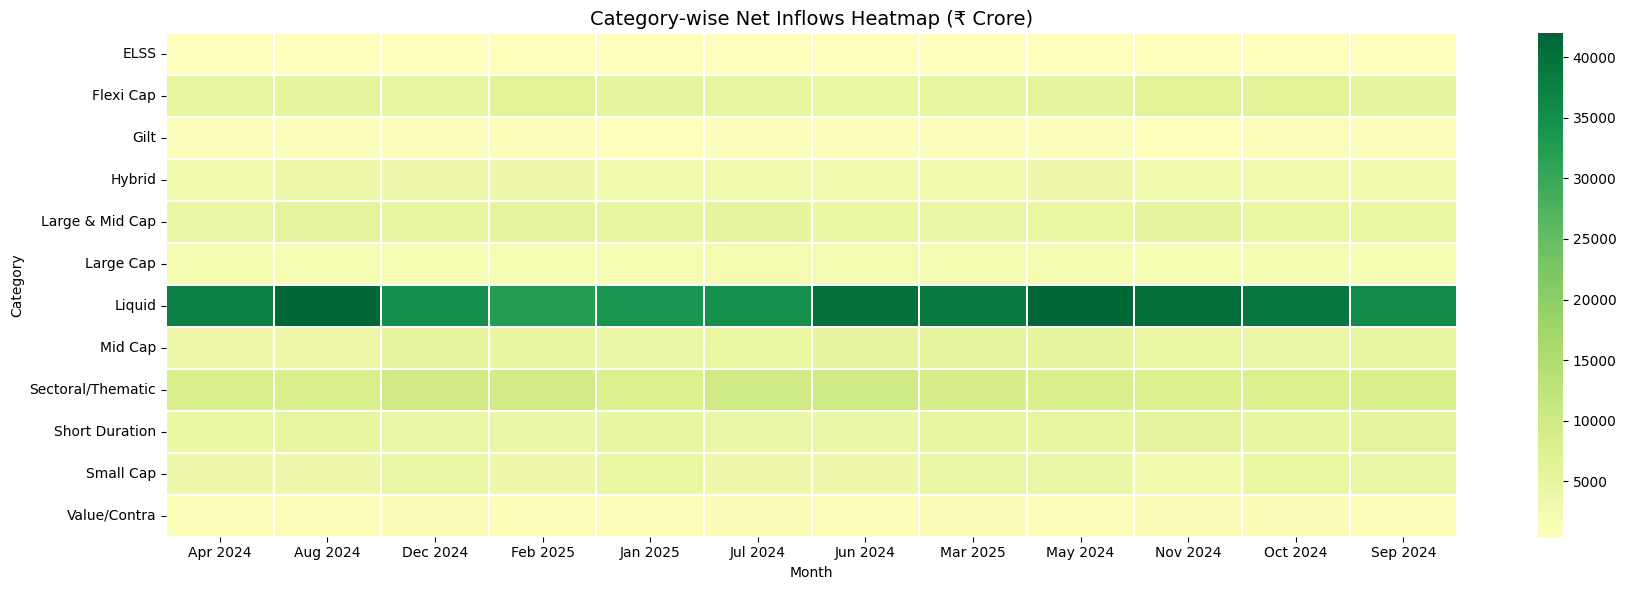

In [11]:
# Adjust col names based on output above
date_col     = "date_id"
category_col = "category"
inflow_col   = "net_inflow_crore"

cat_inflows[date_col] = pd.to_datetime(cat_inflows[date_col], dayfirst=True, errors="coerce")
cat_inflows["month_label"] = cat_inflows[date_col].dt.strftime("%b %Y")

pivot = cat_inflows.pivot_table(
    index=category_col, columns="month_label",
    values=inflow_col, aggfunc="sum"
)

plt.figure(figsize=(18, 6))
sns.heatmap(pivot, cmap="RdYlGn", center=0,
            linewidths=0.3, fmt=".0f", annot=False)
plt.title("Category-wise Net Inflows Heatmap (₹ Crore)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(f"{CHARTS}/04_category_heatmap.png", dpi=150)
plt.show()

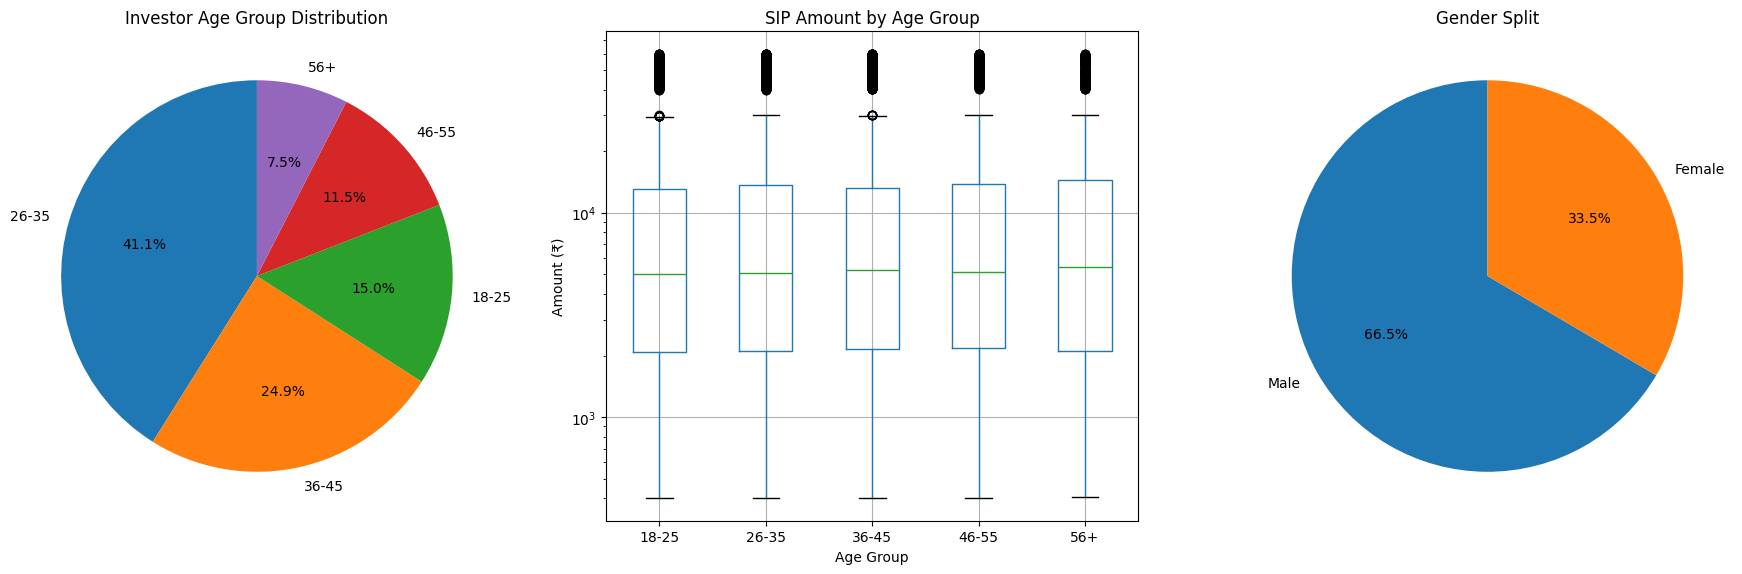

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie — age group
age_counts = transactions["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution")

# Box plot — SIP amount by age group
sip_only = transactions[transactions["transaction_type"] == "SIP"]
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
sip_only["age_group"] = pd.Categorical(sip_only["age_group"], categories=age_order, ordered=True)
sip_only.boxplot(column="amount_inr", by="age_group", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Amount (₹)")
plt.sca(axes[1])
plt.yscale("log")

# Pie — gender split
gender_counts = transactions["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
axes[2].set_title("Gender Split")

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{CHARTS}/05_demographics.png", dpi=150)
plt.show()

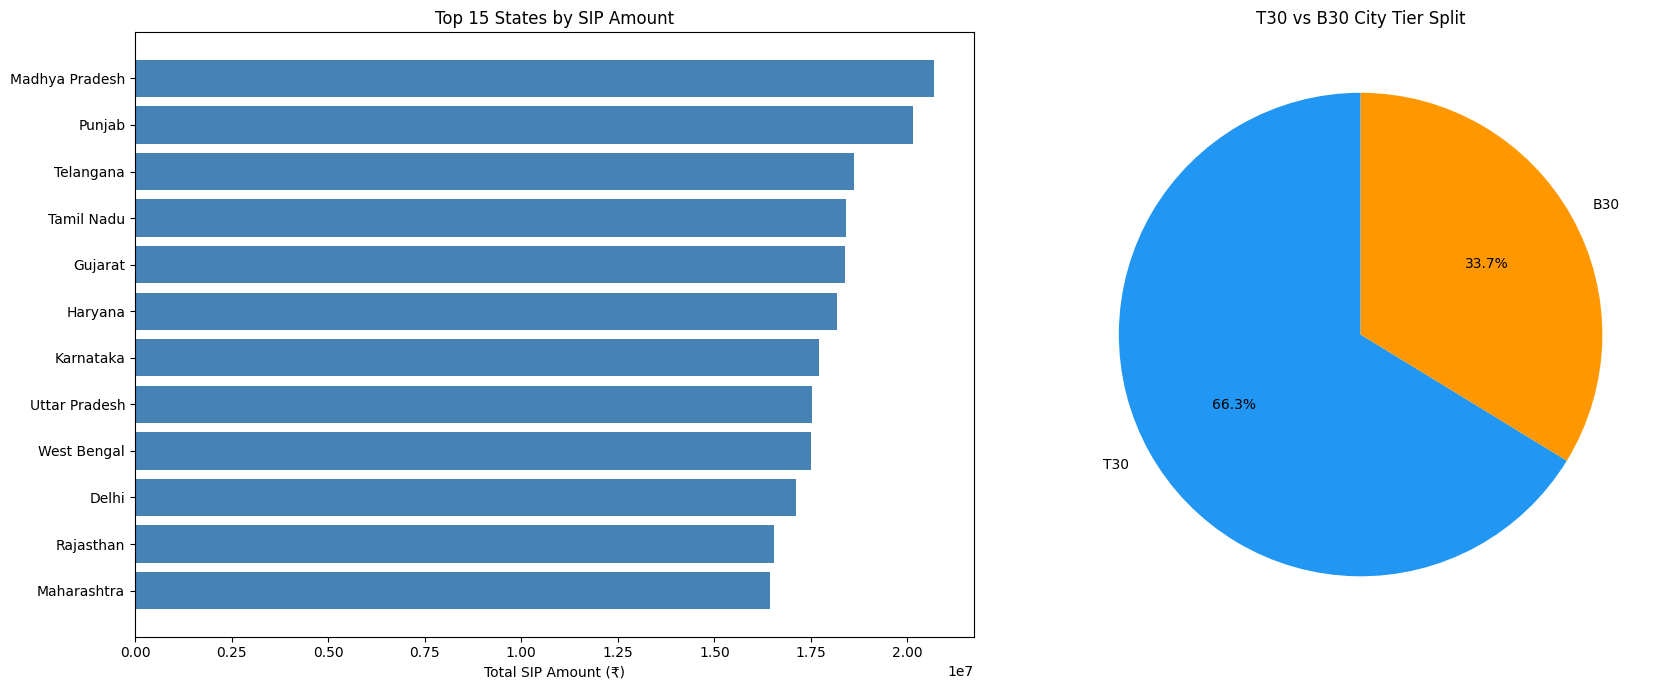

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar — SIP by state
state_sip = (transactions[transactions["transaction_type"] == "SIP"]
             .groupby("state")["amount_inr"].sum()
             .sort_values(ascending=True)
             .tail(15))

axes[0].barh(state_sip.index, state_sip.values, color="steelblue")
axes[0].set_title("Top 15 States by SIP Amount")
axes[0].set_xlabel("Total SIP Amount (₹)")

# Pie — T30 vs B30
tier_counts = transactions["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90,
            colors=["#2196F3", "#FF9800"])
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig(f"{CHARTS}/06_geographic.png", dpi=150)
plt.show()

In [14]:
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore', 'date_id']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore    date_id  
0                 0.80                 1.33 2022-01-01  
1                 0.83                 1.39 2022-04-01  
2                 0.83                 1.38 2022-07-01  
3                 0.85                 1.41 2022-10-01  
4                 0.89                 1.48 2023-01-01  


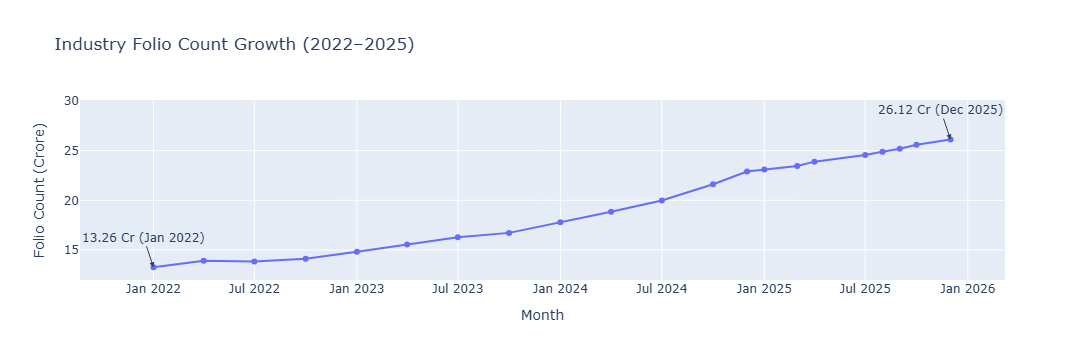

In [15]:
date_col  = "date_id"
folio_col = "total_folios_crore"

folio[date_col] = pd.to_datetime(folio[date_col], dayfirst=True, errors="coerce")
folio = folio.sort_values(date_col)

fig = px.line(
    folio, x=date_col, y=folio_col,
    title="Industry Folio Count Growth (2022–2025)",
    labels={date_col: "Month", folio_col: "Folio Count (Crore)"},
    markers=True
)

# Mark milestones
milestones = {
    "13.26 Cr\n(Jan 2022)": folio[date_col].min(),
    "26.12 Cr\n(Dec 2025)": folio[date_col].max()
}
for label, date in milestones.items():
    row = folio[folio[date_col] == date]
    if not row.empty:
        fig.add_annotation(
            x=date, y=row[folio_col].values[0],
            text=label, showarrow=True, arrowhead=2
        )

fig.write_html(f"{CHARTS}/07_folio_growth.html")
fig.show()

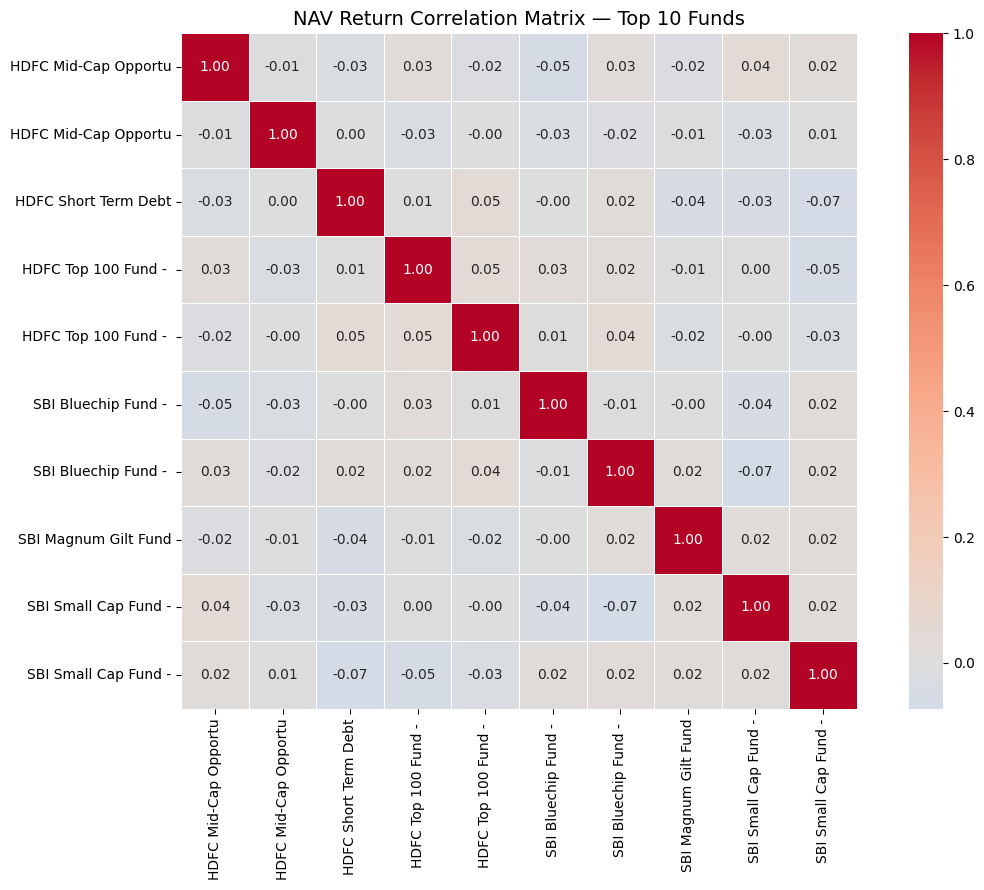

In [16]:
# Pick 10 funds
top10_codes = fund_master["amfi_code"].head(10).tolist()
nav_top10 = nav_history[nav_history["amfi_code"].isin(top10_codes)].copy()
nav_top10 = nav_top10.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")

# Pivot to wide format
nav_pivot = nav_top10.pivot_table(
    index="date_id", columns="scheme_name", values="nav"
)

# Daily returns
returns = nav_pivot.pct_change().dropna()
corr = returns.corr()

# Shorten names for display
corr.columns = [c[:20] for c in corr.columns]
corr.index   = [i[:20] for i in corr.index]

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("NAV Return Correlation Matrix — Top 10 Funds", fontsize=14)
plt.tight_layout()
plt.savefig(f"{CHARTS}/08_correlation_matrix.png", dpi=150)
plt.show()

In [17]:
print(portfolio.columns.tolist())
print(portfolio.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date', 'date_id']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date    date_id  
0           737.09            6011.08     2025-12-31 2025-12-31  
1            88.97            1074.65     2025-12-31 2025-12-31  
2           208.45            5964.59     2025-12-31 2025-12-31  
3           161.32            3748.82     2025-12-31 2025-12-31  
4           725.90            1321.45     2025-12-31

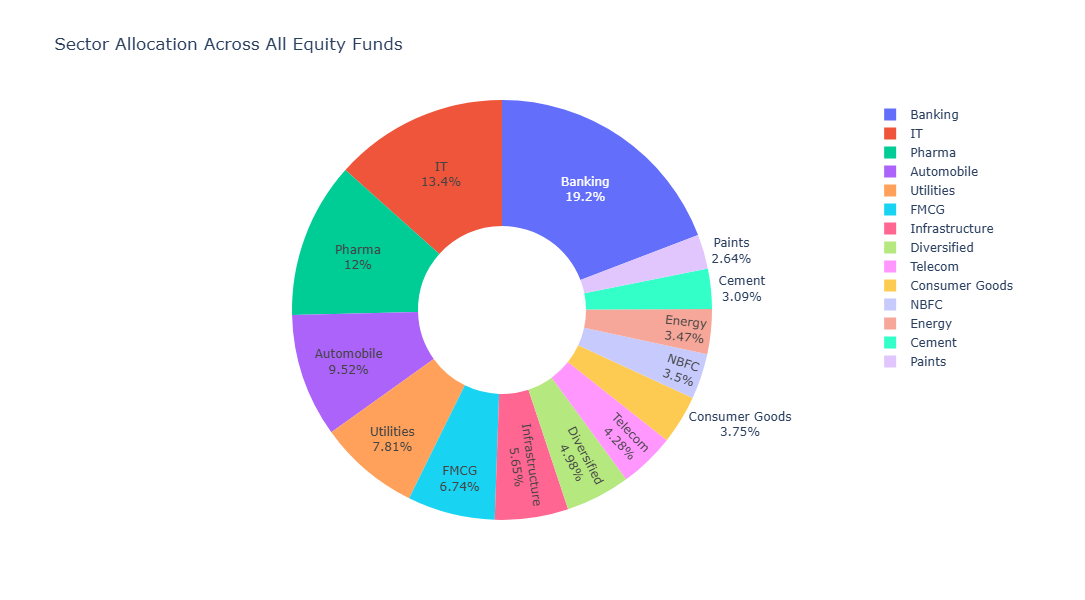

In [18]:
sector_col  = [c for c in portfolio.columns if "sector" in c.lower()][0]
weight_col  = [c for c in portfolio.columns if "weight" in c.lower() or "pct" in c.lower()][0]

sector_agg = portfolio.groupby(sector_col)[weight_col].sum().sort_values(ascending=False)

fig = go.Figure(go.Pie(
    labels=sector_agg.index,
    values=sector_agg.values,
    hole=0.4,
    textinfo="label+percent"
))
fig.update_layout(title="Sector Allocation Across All Equity Funds", height=600)
fig.write_html(f"{CHARTS}/09_sector_donut.html")
fig.show()

## 📊 EDA Finding 1 — NAV Growth
Large cap funds showed consistent 12–15% CAGR from 2022–2026,
with a sharp bull run in 2023 driven by post-COVID recovery.
→ See Chart 1: NAV Trends

## 📊 EDA Finding 2 — SBI AUM Dominance
SBI Mutual Fund manages ₹12.5L Cr+ AUM, nearly 2x the second-largest
fund house, making it the undisputed market leader.
→ See Chart 2: AUM Growth

## 📊 EDA Finding 3 — SIP All-Time High
Monthly SIP inflows crossed ₹31,002 Cr in December 2025,
reflecting the growing retail investor participation in equity markets.
→ See Chart 3: SIP Trend

## 📊 EDA Finding 4 — Equity Category Dominance
Equity fund inflows dominate the heatmap year-round,
while debt funds see periodic outflows during rate hike cycles.
→ See Chart 4: Category Heatmap

## 📊 EDA Finding 5 — Young Investor Base
The 26–35 age group contributes the highest SIP volumes,
indicating a young, digitally-native investor base driving MF growth.
→ See Chart 5: Demographics

## 📊 EDA Finding 6 — Maharashtra Leads
Maharashtra accounts for the highest SIP amounts, followed by
Delhi and Karnataka, reflecting metro concentration of investors.
→ See Chart 6: Geographic

## 📊 EDA Finding 7 — Folio Count Doubled
Total folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025),
nearly doubling in 4 years — a sign of deep market penetration.
→ See Chart 7: Folio Growth

## 📊 EDA Finding 8 — High Intra-Category Correlation
Large cap funds show 0.90+ pairwise return correlations,
suggesting limited diversification benefit within the same category.
→ See Chart 8: Correlation Matrix

## 📊 EDA Finding 9 — Financial Services Dominates
Financial services sector accounts for 25–30% of portfolio holdings
across all equity funds, reflecting index composition.
→ See Chart 9: Sector Donut

## 📊 EDA Finding 10 — Direct Plans Outperform
Direct plan funds consistently show 1–2% higher returns than
regular plans due to lower expense ratios (0.5–0.9% vs 1.4–1.6%).
→ See Chart 7: scheme_performance data